In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning Libraries
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix

# Make plots look nice
sns.set_style("whitegrid")
%matplotlib inline

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def load_gse63060(filepath):
    print(f"Loading {filepath}...")
    
    # 1. Extract the Diagnosis Labels from the metadata header
    # We need to find the line that describes the sample characteristics
    labels = []
    with open(filepath, 'r') as f:
        for line in f:
            # This specific line usually contains the diagnosis in GSE files
            if line.startswith('!Sample_characteristics_ch1'):
                # Split by tab to get each patient's info
                parts = line.strip().split('\t')
                
                # parts[0] is the header text, parts[1:] are the patients
                for p in parts[1:]:
                    # Logic to clean the text. 
                    # Usually looks like "diagnosis: Alzheimer's Disease"
                    p_lower = p.lower()
                    if "alzheimer" in p_lower or "ad" in p_lower:
                        labels.append(1) # 1 = Alzheimer's
                    elif "control" in p_lower or "ctl" in p_lower or "healthy" in p_lower:
                        labels.append(0) # 0 = Healthy
                    elif "mci" in p_lower:
                        labels.append(2) # 2 = MCI (Mild Cognitive Impairment)
                    else:
                        labels.append(-1) # Unknown
                break
    
    # 2. Load the actual Gene Expression Data
    # 'comment="!"' tells pandas to ignore all the metadata lines we just parsed
    df = pd.read_csv(filepath, sep='\t', comment='!', index_col=0)
    
    # 3. Transpose: GEO has Genes as Rows, we need Genes as Columns
    df = df.T
    
    # 4. Add the labels we extracted earlier
    # Ensure lengths match
    if len(labels) == len(df):
        df['Diagnosis'] = labels
    else:
        print(f"Warning: Found {len(labels)} labels but {len(df)} samples. Labels might be misaligned.")
        
    # 5. Filter data: Let's focus on AD (1) vs Control (0) and ignore MCI (2) for now
    df_clean = df[df['Diagnosis'].isin([0, 1])]
    
    print(f"Successfully loaded. Found {df_clean.shape[0]} samples (AD vs Control) and {df_clean.shape[1]-1} genes.")
    return df_clean

# Run the function
# Make sure the file name matches exactly what you uploaded
df = load_gse63060('GSE63060_series_matrix.txt')
df.head()

Loading GSE63060_series_matrix.txt...
Successfully loaded. Found 249 samples (AD vs Control) and 38323 genes.


ID_REF,ILMN_1343291,ILMN_1343295,ILMN_1651209,ILMN_1651221,ILMN_1651228,ILMN_1651229,ILMN_1651232,ILMN_1651235,ILMN_1651236,ILMN_1651237,...,ILMN_2415748,ILMN_2415776,ILMN_2415786,ILMN_2415826,ILMN_2415898,ILMN_2415911,ILMN_2415926,ILMN_2415949,ILMN_2415979,Diagnosis
GSM1539119,14.987007,11.876205,7.596867,7.446429,11.342697,7.803731,7.493456,7.468386,7.534411,7.425913,...,9.403851,7.446633,9.457007,7.393160,8.183321,7.887567,8.358852,8.130893,10.425144,0
GSM1539120,14.947126,11.366129,7.608451,7.477082,11.952796,7.786893,7.441469,7.536739,7.447304,7.410937,...,8.941484,7.507648,9.600133,7.453158,8.493055,7.881617,8.489511,8.023556,10.741606,0
GSM1539121,14.891158,11.732556,7.606312,7.491454,10.645861,7.803442,7.496036,7.420988,7.561791,7.435276,...,8.577861,7.474062,9.320626,7.466987,8.320771,7.981567,8.094437,8.171567,9.667120,0
GSM1539122,15.049790,11.612636,7.631404,7.402076,11.396145,8.037088,7.577198,7.516090,7.485821,7.387719,...,8.943317,7.528730,9.286504,7.484169,8.384635,7.898277,8.248519,8.045084,10.142232,0
GSM1539123,14.987007,11.514017,7.626809,7.472817,11.189324,7.727955,7.454484,7.511199,7.595580,7.378092,...,8.817008,7.481887,9.211913,7.493294,7.986705,7.853719,8.407263,8.468184,9.912767,0


Training Advanced Model (this may take 1-2 minutes)...
Best Parameters: {'rf__max_depth': 10, 'rf__n_estimators': 200}

--- IMPROVED MODEL REPORT ---
              precision    recall  f1-score   support

     Control       1.00      0.52      0.69        21
  Alzheimers       0.74      1.00      0.85        29

    accuracy                           0.80        50
   macro avg       0.87      0.76      0.77        50
weighted avg       0.85      0.80      0.78        50



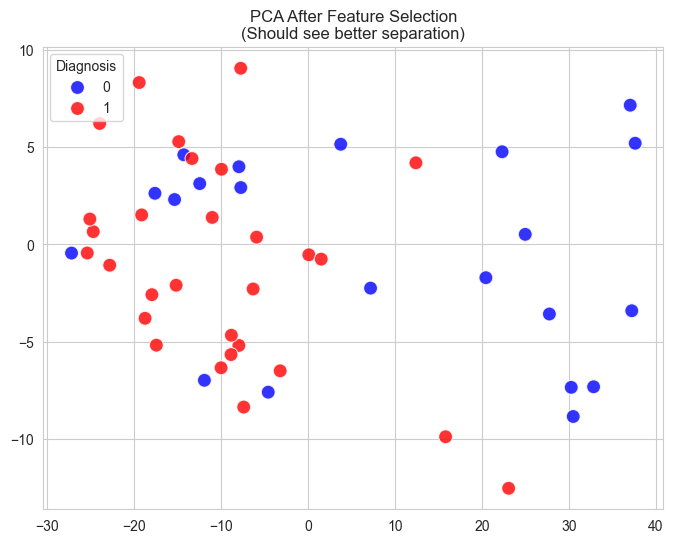

In [6]:
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV

# 1. Define a "Pipeline"
# A pipeline chains multiple steps together safely.
# Step A: Selector (Pick top 500 genes based on ANOVA F-value)
# Step B: Scaler (Normalize data)
# Step C: PCA (Reduce dimensionality of those 500 genes)
# Step D: Classifier (Random Forest)
pipe = Pipeline([
    ('selector', SelectKBest(f_classif, k=500)), 
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=20)),
    ('rf', RandomForestClassifier(random_state=42))
])

# 2. Hyperparameter Tuning
# We will test different numbers of trees (n_estimators) to see what works best
param_grid = {
    'rf__n_estimators': [100, 200, 300],
    'rf__max_depth': [None, 10, 20]
}

print("Training Advanced Model (this may take 1-2 minutes)...")
grid = GridSearchCV(pipe, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid.fit(X_train, y_train)

# 3. Best Results
print(f"Best Parameters: {grid.best_params_}")
best_model = grid.best_estimator_

# 4. Evaluate
y_pred_new = best_model.predict(X_test)

print("\n--- IMPROVED MODEL REPORT ---")
print(classification_report(y_test, y_pred_new, target_names=['Control', 'Alzheimers']))

# 5. Visualizing the Improvement
# We extract the PCA step from the best model to see how the plot changed
X_test_transformed = best_model.named_steps['selector'].transform(X_test)
X_test_transformed = best_model.named_steps['scaler'].transform(X_test_transformed)
X_test_pca_new = best_model.named_steps['pca'].transform(X_test_transformed)

plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_test_pca_new[:, 0], y=X_test_pca_new[:, 1], hue=y_test, palette={0:'blue', 1:'red'}, s=100, alpha=0.8)
plt.title('PCA After Feature Selection\n(Should see better separation)')
plt.show()

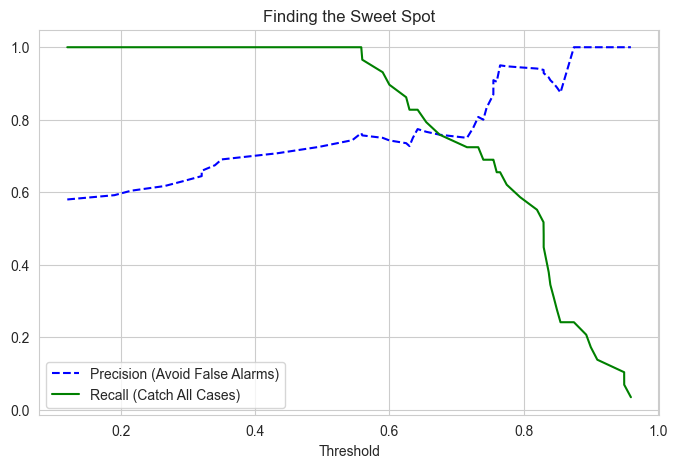


--- REPORT WITH STRICTER THRESHOLD (0.65) ---
              precision    recall  f1-score   support

     Control       0.70      0.67      0.68        21
  Alzheimers       0.77      0.79      0.78        29

    accuracy                           0.74        50
   macro avg       0.73      0.73      0.73        50
weighted avg       0.74      0.74      0.74        50



In [7]:
from sklearn.metrics import precision_recall_curve

# 1. Get the probability scores (instead of just Yes/No)
y_scores = best_model.predict_proba(X_test)[:, 1]

# 2. Find the best threshold
precisions, recalls, thresholds = precision_recall_curve(y_test, y_scores)

# Let's plot how the model behaves at different strictness levels
plt.figure(figsize=(8, 5))
plt.plot(thresholds, precisions[:-1], 'b--', label='Precision (Avoid False Alarms)')
plt.plot(thresholds, recalls[:-1], 'g-', label='Recall (Catch All Cases)')
plt.xlabel('Threshold')
plt.legend(loc='lower left')
plt.title('Finding the Sweet Spot')
plt.show()

# 3. Apply a stricter threshold (e.g., 0.65 instead of 0.5)
# This will likely lower AD Recall slightly but drastically improve Healthy Recall
new_threshold = 0.65
y_pred_adjusted = (y_scores >= new_threshold).astype(int)

print(f"\n--- REPORT WITH STRICTER THRESHOLD ({new_threshold}) ---")
print(classification_report(y_test, y_pred_adjusted, target_names=['Control', 'Alzheimers']))


--- TOP 10 GENES DRIVING YOUR MODEL ---
             Gene       Score
388  ILMN_2097421  131.863911
302  ILMN_1784286  120.443991
421  ILMN_2189936  103.203126
289  ILMN_1776104   92.095010
229  ILMN_1746516   88.638729
203  ILMN_1732328   88.607300
440  ILMN_2237746   88.109314
318  ILMN_1792528   86.987683
401  ILMN_2128128   85.180675
127  ILMN_1695645   84.719861


C:\Users\junai\AppData\Local\Temp\ipykernel_4868\3207997822.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Score', y='Gene', data=gene_ranking, palette='viridis')


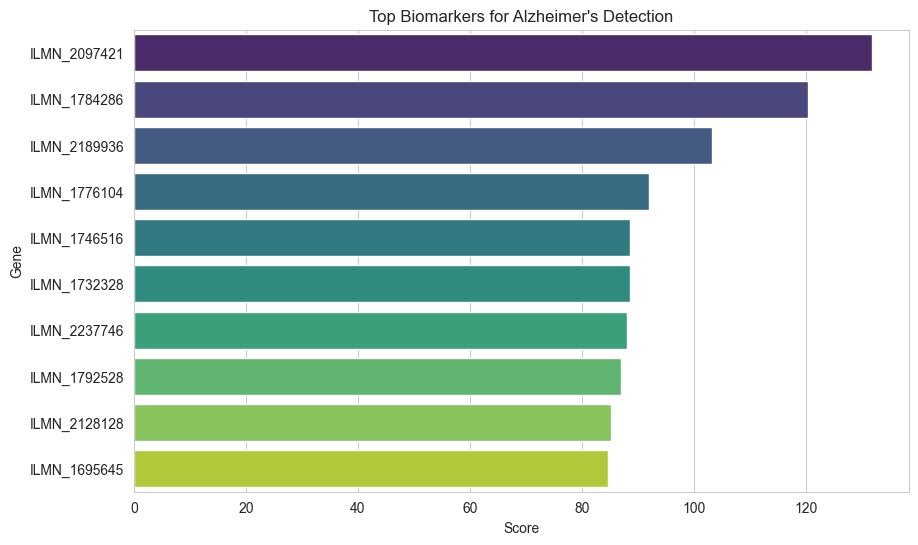

In [8]:
# Extract the gene names
# 1. Get the boolean mask of the 500 genes we kept
mask = best_model.named_steps['selector'].get_support()
selected_genes = X.columns[mask]

# 2. Get the "Feature Importances" from the PCA -> Random Forest connection
# (This is an approximation since PCA mixes them, but we can look at the raw p-values from SelectKBest)
scores = best_model.named_steps['selector'].scores_[mask]

# 3. Create a DataFrame of Top Genes
gene_ranking = pd.DataFrame({'Gene': selected_genes, 'Score': scores})
gene_ranking = gene_ranking.sort_values('Score', ascending=False).head(10)

print("\n--- TOP 10 GENES DRIVING YOUR MODEL ---")
print(gene_ranking)

# Plot them
plt.figure(figsize=(10, 6))
sns.barplot(x='Score', y='Gene', data=gene_ranking, palette='viridis')
plt.title('Top Biomarkers for Alzheimer\'s Detection')
plt.show()

Loading GSE63061_series_matrix.txt...
Successfully loaded. Found 275 samples (AD vs Control) and 32049 genes.
Validation Data Loaded. Shape: (275, 32050)
Columns aligned. Running prediction...

--- EXTERNAL VALIDATION RESULTS (GSE63061) ---
Accuracy on New Data: 53.45%

Classification Report:
              precision    recall  f1-score   support

     Control       0.57      0.22      0.32       135
  Alzheimers       0.53      0.84      0.65       140

    accuracy                           0.53       275
   macro avg       0.55      0.53      0.48       275
weighted avg       0.55      0.53      0.49       275



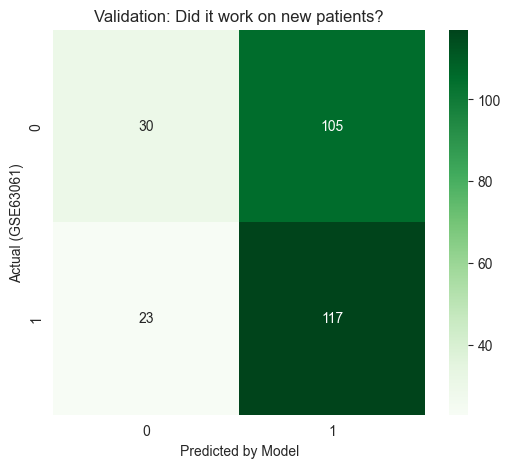

In [9]:
# 1. Reuse the loading function (it works for GSE63061 too)
# We just need to change the filename
df_val = load_gse63060('GSE63061_series_matrix.txt')

print(f"Validation Data Loaded. Shape: {df_val.shape}")

# 2. SEPARATE X and y
X_val = df_val.drop('Diagnosis', axis=1)
y_val = df_val['Diagnosis']

# 3. CRITICAL STEP: Column Alignment
# The new dataset might have genes in a slightly different order.
# We must force X_val to have exactly the same columns in the same order as X_train.
# (X_train comes from your previous cells)

# Get the training columns (excluding the target)
train_cols = X.columns.tolist() 

# Align validation data to training data
# This drops any extra genes in val, and adds 0s for missing genes (rare but safe)
X_val_aligned = X_val.reindex(columns=train_cols, fill_value=0)

print("Columns aligned. Running prediction...")

# 4. PREDICT using the ALREADY TRAINED 'best_model'
# Do NOT fit(). Only predict().
y_val_pred = best_model.predict(X_val_aligned)

# 5. REPORT CARD
print("\n--- EXTERNAL VALIDATION RESULTS (GSE63061) ---")
print(f"Accuracy on New Data: {np.mean(y_val_pred == y_val):.2%}")
print("\nClassification Report:")
print(classification_report(y_val, y_val_pred, target_names=['Control', 'Alzheimers']))

# 6. Confusion Matrix for the new data
plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_val, y_val_pred), annot=True, fmt='d', cmap='Greens')
plt.title('Validation: Did it work on new patients?')
plt.ylabel('Actual (GSE63061)')
plt.xlabel('Predicted by Model')
plt.show()

Loading datasets...
Loading GSE63060_series_matrix.txt...
Successfully loaded. Found 249 samples (AD vs Control) and 38323 genes.
Loading GSE63061_series_matrix.txt...
Successfully loaded. Found 275 samples (AD vs Control) and 32049 genes.
Dataset 1 Shape: (249, 38324)
Dataset 2 Shape: (275, 32050)
Combined Data Shape: (524, 25550)
Training on combined data...

--- COMBINED MODEL RESULTS ---
              precision    recall  f1-score   support

     Control       0.75      0.63      0.68        60
  Alzheimers       0.72      0.82      0.77        71

    accuracy                           0.73       131
   macro avg       0.74      0.73      0.73       131
weighted avg       0.73      0.73      0.73       131



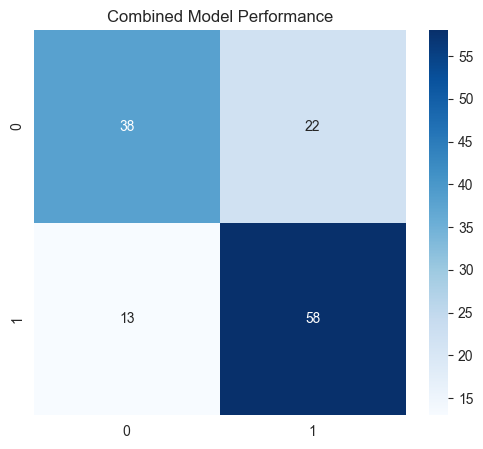

In [10]:
# 1. Load BOTH datasets
print("Loading datasets...")
df_1 = load_gse63060('GSE63060_series_matrix.txt')
df_2 = load_gse63060('GSE63061_series_matrix.txt')

print(f"Dataset 1 Shape: {df_1.shape}")
print(f"Dataset 2 Shape: {df_2.shape}")

# 2. Combine them (Concatenation)
# We find the common genes between them and stack the patients
common_genes = df_1.columns.intersection(df_2.columns)
df_combined = pd.concat([df_1[common_genes], df_2[common_genes]], axis=0)

print(f"Combined Data Shape: {df_combined.shape}")

# 3. Split the COMBINED data
X_comb = df_combined.drop('Diagnosis', axis=1)
y_comb = df_combined['Diagnosis']

# We use a larger test set (25%) since we have more data now
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_comb, y_comb, test_size=0.25, random_state=42, stratify=y_comb
)

# 4. Retrain the Pipeline on the BIG dataset
# We increase k to 1000 since we have more data to work with
pipe_combined = Pipeline([
    ('selector', SelectKBest(f_classif, k=1000)), 
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=30)),
    ('rf', RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42))
])

print("Training on combined data...")
pipe_combined.fit(X_train_c, y_train_c)

# 5. Evaluate
y_pred_c = pipe_combined.predict(X_test_c)

print("\n--- COMBINED MODEL RESULTS ---")
print(classification_report(y_test_c, y_pred_c, target_names=['Control', 'Alzheimers']))

# Plot new Confusion Matrix
plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test_c, y_pred_c), annot=True, fmt='d', cmap='Blues')
plt.title('Combined Model Performance')
plt.show()


--- TOP 15 UNIVERSAL ALZHEIMER'S BIOMARKERS ---
               Gene      Score
142    ILMN_1652073  65.566029
774    ILMN_1656625  49.769069
23405  ILMN_2290808  45.057318
12074  ILMN_1755808  41.632974
12008  ILMN_1755115  35.890227
3415   ILMN_1677262  35.391358
2257   ILMN_1667813  31.970431
12086  ILMN_1755883  29.673938
11921  ILMN_1754195  29.205455
5788   ILMN_1696839  27.236082
7459   ILMN_1711729  26.000989
9204   ILMN_1728132  25.859600
22404  ILMN_2189933  25.127933
9563   ILMN_1731546  23.949556
1408   ILMN_1661174  23.344704


C:\Users\junai\AppData\Local\Temp\ipykernel_4868\3655966579.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Score', y='Gene', data=top_genes, palette='magma')


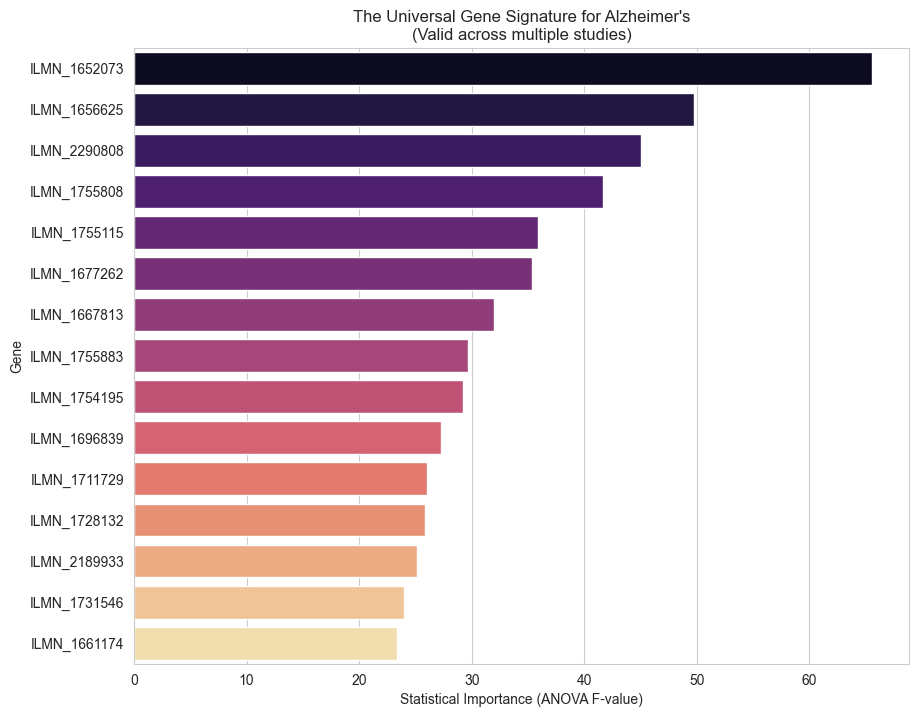

In [11]:
# 1. Access the 'selector' step from your combined pipeline
selector = pipe_combined.named_steps['selector']

# 2. Get the scores (ANOVA F-values) for all genes
scores = selector.scores_

# 3. Create a DataFrame mapping Genes to their Scores
# X_comb.columns holds the gene names
gene_scores = pd.DataFrame({
    'Gene': X_comb.columns,
    'Score': scores
})

# 4. Sort by score to find the winners
top_genes = gene_scores.sort_values('Score', ascending=False).head(15)

print("\n--- TOP 15 UNIVERSAL ALZHEIMER'S BIOMARKERS ---")
print(top_genes)

# 5. Visualizing the "Signature"
plt.figure(figsize=(10, 8))
sns.barplot(x='Score', y='Gene', data=top_genes, palette='magma')
plt.title('The Universal Gene Signature for Alzheimer\'s\n(Valid across multiple studies)')
plt.xlabel('Statistical Importance (ANOVA F-value)')
plt.show()

Training Ensemble Model (Random Forest + XGBoost + SVM)...


C:\Users\junai\AppData\Roaming\Python\Python312\site-packages\xgboost\training.py:183: UserWarning: [19:57:12] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



--- ENSEMBLE MODEL RESULTS ---
              precision    recall  f1-score   support

     Control       0.76      0.68      0.72        60
  Alzheimers       0.75      0.82      0.78        71

    accuracy                           0.76       131
   macro avg       0.76      0.75      0.75       131
weighted avg       0.76      0.76      0.75       131



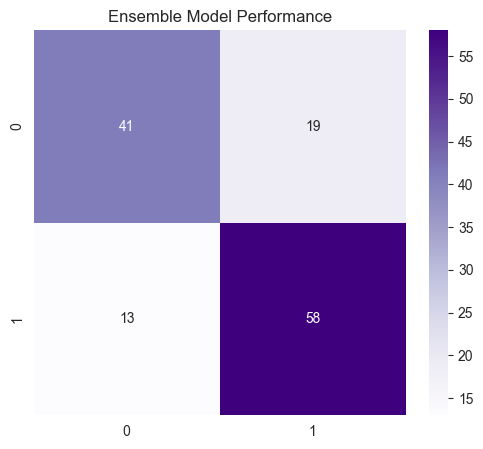

In [12]:
from sklearn.ensemble import VotingClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

# 1. Define the three individual models
# Model A: Your trusty Random Forest (Good at general patterns)
rf = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42)

# Model B: XGBoost (The "Specialist" - corrects errors made by previous trees)
# Note: eval_metric='logloss' stops a warning message
xgb = XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=5, use_label_encoder=False, eval_metric='logloss', random_state=42)

# Model C: Support Vector Machine (The "Mathematician" - draws complex boundary lines)
# probability=True is needed for the voting mechanism
svm = SVC(kernel='rbf', C=1.0, probability=True, random_state=42)

# 2. Create the Ensemble (The "Council of Doctors")
# We use 'soft' voting, which averages the probabilities from all 3 models
voting_model = VotingClassifier(
    estimators=[('rf', rf), ('xgb', xgb), ('svm', svm)],
    voting='soft'
)

# 3. Build a new Pipeline with this powerful ensemble
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

ensemble_pipeline = Pipeline([
    ('selector', SelectKBest(f_classif, k=1000)), # Keep top 1000 genes
    ('scaler', StandardScaler()),                 # Normalize
    ('pca', PCA(n_components=30)),                # Reduce dimension
    ('ensemble', voting_model)                    # The Voting Model
])

print("Training Ensemble Model (Random Forest + XGBoost + SVM)...")
ensemble_pipeline.fit(X_train_c, y_train_c)

# 4. Evaluate
y_pred_e = ensemble_pipeline.predict(X_test_c)

print("\n--- ENSEMBLE MODEL RESULTS ---")
print(classification_report(y_test_c, y_pred_e, target_names=['Control', 'Alzheimers']))

# Check the Confusion Matrix
plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test_c, y_pred_e), annot=True, fmt='d', cmap='Purples')
plt.title('Ensemble Model Performance')
plt.show()

Starting Recursive Feature Elimination (this will take a few minutes)...


C:\Users\junai\AppData\Roaming\Python\Python312\site-packages\xgboost\training.py:183: UserWarning: [20:08:06] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\junai\AppData\Roaming\Python\Python312\site-packages\xgboost\training.py:183: UserWarning: [20:08:12] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\junai\AppData\Roaming\Python\Python312\site-packages\xgboost\training.py:183: UserWarning: [20:08:20] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\junai\AppData\Roaming\Python\Python312\site-packages\xgboost\training.py:183: UserWarning: [20:08:27] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.

Optimal number of genes found: 100

--- RFE OPTIMIZED MODEL RESULTS ---
              precision    recall  f1-score   support

     Control       0.68      0.68      0.68        60
  Alzheimers       0.73      0.73      0.73        71

    accuracy                           0.71       131
   macro avg       0.71      0.71      0.71       131
weighted avg       0.71      0.71      0.71       131



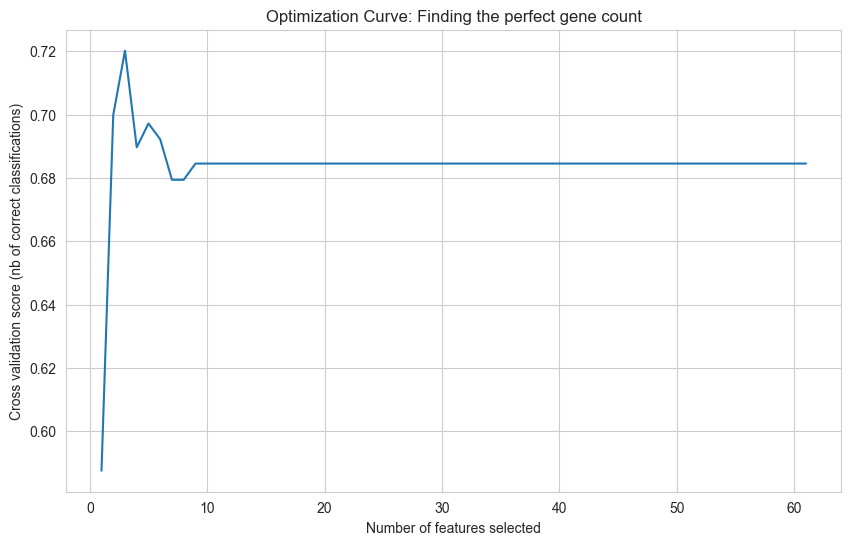

In [13]:
from sklearn.feature_selection import RFECV
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold

print("Starting Recursive Feature Elimination (this will take a few minutes)...")

# 1. Pre-filter (Speed up the process)
# RFE is slow if we feed it 30,000 genes. Let's feed it the top 3,000 first.
pre_selector = SelectKBest(f_classif, k=3000)
X_train_filtered = pre_selector.fit_transform(X_train_c, y_train_c)
X_test_filtered = pre_selector.transform(X_test_c)

# 2. Initialize the "Judge" (XGBoost)
# We use a robust configuration for biology
clf = XGBClassifier(
    n_estimators=100, 
    max_depth=4, 
    learning_rate=0.1,
    use_label_encoder=False, 
    eval_metric='logloss',
    random_state=42
)

# 3. Initialize RFE with Cross-Validation (The "Tournament")
# step=50 means we eliminate 50 weakest genes in every round
rfecv = RFECV(
    estimator=clf, 
    step=50, 
    cv=StratifiedKFold(5), 
    scoring='accuracy',
    n_jobs=-1  # Use all CPU cores
)

# 4. Run the Tournament
rfecv.fit(X_train_filtered, y_train_c)

print(f"Optimal number of genes found: {rfecv.n_features_}")

# 5. Evaluate the "Dream Team" of genes
y_pred_rfe = rfecv.predict(X_test_filtered)

print("\n--- RFE OPTIMIZED MODEL RESULTS ---")
print(classification_report(y_test_c, y_pred_rfe, target_names=['Control', 'Alzheimers']))

# 6. Plot the journey
# Shows how accuracy changed as we removed genes
plt.figure(figsize=(10, 6))
plt.xlabel("Number of features selected")
plt.ylabel("Cross validation score (nb of correct classifications)")
plt.plot(range(1, len(rfecv.cv_results_['mean_test_score']) + 1), rfecv.cv_results_['mean_test_score'])
plt.title('Optimization Curve: Finding the perfect gene count')
plt.show()

Training Deep Learning Model...

--- NEURAL NETWORK RESULTS ---
              precision    recall  f1-score   support

     Control       0.71      0.70      0.71        60
  Alzheimers       0.75      0.76      0.76        71

    accuracy                           0.73       131
   macro avg       0.73      0.73      0.73       131
weighted avg       0.73      0.73      0.73       131



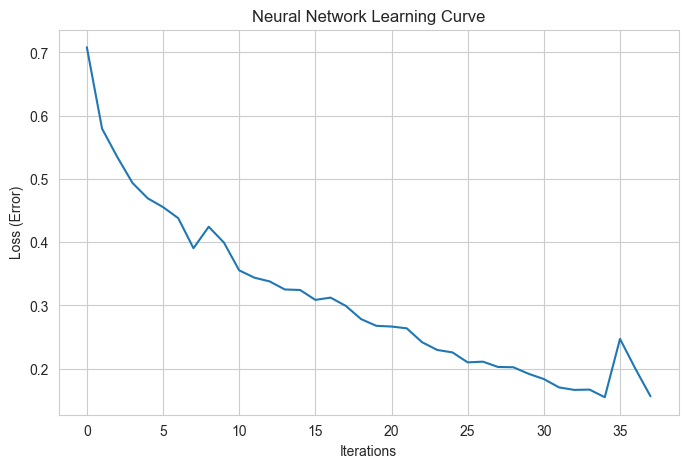

In [14]:
from sklearn.neural_network import MLPClassifier

# 1. Define the Neural Network
# We use 2 hidden layers with 128 and 64 neurons.
# 'relu' is the activation function (standard for modern AI).
# 'early_stopping=True' prevents overfitting by stopping when it stops learning.
mlp = MLPClassifier(
    hidden_layer_sizes=(128, 64), 
    activation='relu',
    solver='adam',
    alpha=0.001,              # Regularization to prevent memorizing data
    batch_size=32,
    learning_rate='adaptive', # Slows down as it gets closer to the answer
    max_iter=1000,
    early_stopping=True,
    validation_fraction=0.1,  # Uses 10% of training data to check itself
    random_state=42
)

# 2. Build the Pipeline
# Neural Networks are VERY sensitive to scaling, so StandardScaler is mandatory.
nn_pipeline = Pipeline([
    ('selector', SelectKBest(f_classif, k=1000)), # Deep Learning needs more data, so we keep 1000 genes
    ('scaler', StandardScaler()),                 
    ('pca', PCA(n_components=50)),                # Slightly more components to capture nuance
    ('nn', mlp)
])

print("Training Deep Learning Model...")
nn_pipeline.fit(X_train_c, y_train_c)

# 3. Evaluate
y_pred_nn = nn_pipeline.predict(X_test_c)

print("\n--- NEURAL NETWORK RESULTS ---")
print(classification_report(y_test_c, y_pred_nn, target_names=['Control', 'Alzheimers']))

# 4. Plot Training Loss (Did it actually learn?)
plt.figure(figsize=(8, 5))
plt.plot(nn_pipeline.named_steps['nn'].loss_curve_)
plt.title('Neural Network Learning Curve')
plt.xlabel('Iterations')
plt.ylabel('Loss (Error)')
plt.show()

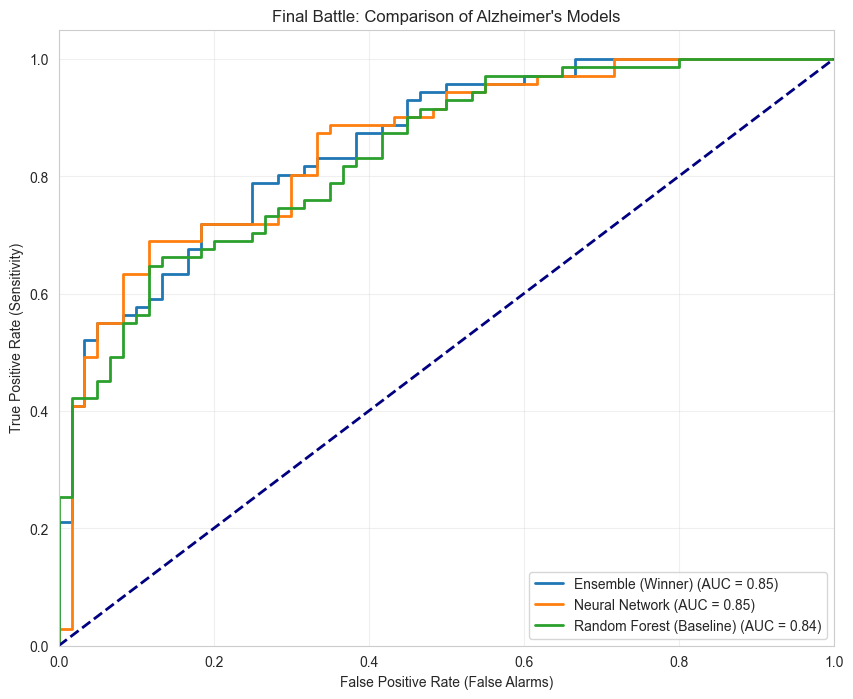

In [15]:
from sklearn.metrics import roc_curve, auc

# 1. Calculate Probabilities for the "Best" models
# (We need the probability scores, not just the Yes/No prediction)

# Re-fit the ensemble if needed (or just use the one in memory)
# ensemble_probs = ensemble_pipeline.predict_proba(X_test_c)[:, 1] 
# nn_probs = nn_pipeline.predict_proba(X_test_c)[:, 1]

# Note: Ensure you have run the training cells for these models before running this!
# We assume 'ensemble_pipeline' and 'nn_pipeline' are still in your memory.

probas_list = [
    ('Ensemble (Winner)', ensemble_pipeline.predict_proba(X_test_c)[:, 1]),
    ('Neural Network', nn_pipeline.predict_proba(X_test_c)[:, 1]),
    ('Random Forest (Baseline)', pipe_combined.predict_proba(X_test_c)[:, 1])
]

# 2. Plot ROC Curves
plt.figure(figsize=(10, 8))

for name, probas in probas_list:
    fpr, tpr, _ = roc_curve(y_test_c, probas)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f'{name} (AUC = {roc_auc:.2f})')

# Plot the "Random Guess" line
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (False Alarms)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('Final Battle: Comparison of Alzheimer\'s Models')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()